# Big assignment 1

## Read before you start

* Provide clear and complete answers in code blocks or markdown. You may add as many as you need.
* Always motivate your answers. This can be done in markdown cells, or in comments in code.
* Submit your results via Brightspace. Use the following filename convention: ``StudentName1_snumber1_StudentName2_snumber2_LargeAssignment1.ipynb``.
* Make sure you submit a fully executed version of the notebook file. The teaching assistants will not run/debug your code during grading.
* Questions? Ask them during the workgroups, or see Brightspace for instructions on how to proceed.

In [1]:
!apt-get update
!apt install jags -y
!pip install pyjags

Hit:1 http://deb.debian.org/debian bullseye InRelease
Hit:2 http://deb.debian.org/debian-security bullseye-security InRelease
Hit:3 http://deb.debian.org/debian bullseye-updates InRelease




jags is already the newest version (4.3.0-3).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.

[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pyjags as pj

print('Using PyJAGS v{:s}'.format(pj.__version__))

plt.rc('axes', titlesize=18)        # fontsize of the axes title
plt.rc('axes', labelsize=18)        # fontsize of the x and y labels
plt.rc('xtick', labelsize=14)       # fontsize of the tick labels
plt.rc('ytick', labelsize=14)       # fontsize of the tick labels
plt.rc('legend', fontsize=12)       # legend fontsize
plt.rc('figure', titlesize=30)      # fontsize of the figure title

Using PyJAGS v1.3.8


# 1. Modelling exam results

In this exercise, we'll use some very small data sets and Bayesian modeling to answer some simple research questions. We'll study the performance of students on multiple choice exams (us teachers are obsessed with these type of examples). We'll be using `pyjags` to construct increasingly complex models for such data.

## 1.1. To study or not to study
Suppose we have an exam of $n = 40$ true-or-false questions, and $m = 15$ students that take this test. We observe the following scores on the exam:

$
\mathbf{k} = (19, 20, 16, 23, 22, 30, 38, 29, 34, 35, 35, 32, 37, 36, 33) \enspace,
$ where $k_i$ is the number of correct answers out of $n$ for student $i$.

If you look closely at these data, it seems as if it captures two different 'types' of students: one type performs reasonably well, whereas the other type reaches only guessing-level performance. 

It would be great if we could figure out to which type each student belongs, and what the success rates (i.e., the probabilities of a correct answer) are for the two groups.

The first steps to modelling this situation consists of writing down the generative model, and drawing the corresponding graphical model. The generative model should include (at least) the following:

- $k_i$: the number of questions answered correctly by student $i$.
- $z_i$: the group label for student $i$ (group 0: guessing; group 1: studying).
- $\theta_i$: the probability student $i$ answers correctly.
- $\psi$: the probability of a correct answer for students in group 0.
- $\phi$: the probability of a correct answer for students in group 1.

You may need to add several (hyper-)parameters yourself!

1. What distribution makes sense for the likelihood $P(k_i \mid n, \ldots)$?

##### Answer Question 1
The binomial distribution would make sense to use as the likelihood for P(k_i|n,...).

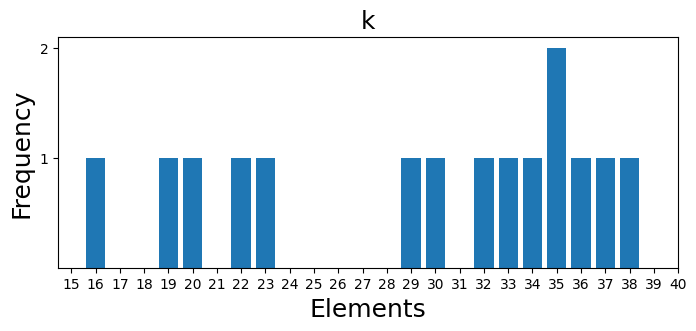

In [3]:
import matplotlib.pyplot as plt
from collections import Counter

# Your list
k = [19, 20, 16, 23, 22, 30, 38, 29, 34, 35, 35, 32, 37, 36, 33]

# Count occurrences
counter = Counter(k)
elements = list(counter.keys())
frequencies = list(counter.values())
x_ticks = [i for i in range(15, 41)]
y_ticks = [i for i in range(1, max(frequencies) + 1)]

# Plot the bar chart

plt.rc('xtick', labelsize=10) 
plt.rc('ytick', labelsize=10) 

plt.figure(figsize=(8, 3))
plt.bar(elements, frequencies)
plt.xlabel("Elements")
plt.ylabel("Frequency")
plt.title("k")
plt.xticks(x_ticks)  
plt.yticks(y_ticks)
plt.show()


2. Write down the generative model for this scenario. Think carefully about:
  - Which variable do you want to learn?
  - Which variable do you want to set to a fixed value (a hyperparameter)?
  - Which variable is observed?
  - Which variables are deterministic transformations of other variables?

Here are two hints:

First, The probability of a correct answer depends on the group a student belongs to ($z_i$). To express this in a generative model, we can use $z_i$ as an _indexing variable_ (this is the same idea as the label variable in a mixture model; that is essentially what we have here!). For example, one could specify:

$$
  \theta_i = \begin{cases}\phi & \text{if $z_i=1$}\\ \psi &\text{if $z_i=0$.}\end{cases}
$$

Second, note that if a student is not in the guessing group, we expect them to perform __better__ than chance level.

##### Answer: Question 2
The generative model for this scenario is:

$k_i \sim Binomial(\theta_i, n)$
$\theta_i \sim \{\phi \text{ if }z_i = 1, \text{and }  \psi \text{ if } z_i = 0$
$z_i \sim Categorical(p)$
$p \sim Beta(a, b)$
$\phi \sim Beta(a', b')$
$\psi = 0.5$
a = 3
b = 2
a' = 3
b' = 2
n = 40

Explanation:
$k_i$ is the number of correct answer out of n for a single student. i is the index with which we differentiate between the students.
$\theta_i$ is the probability that a student answers correctly. This depends on the group that the student is in (guessing or studying)
$z_i$ is a categorical distribution with the two groups studying and guessing. 
$p$ is the probability to be in one of the two groups for $z_i$. Since we do not know this probability, we can infer it from the data. We use a beta distribution with parameters a and bas a prior to model this (We could also take the exact p value from the data but we cannot yet be 100% sure which category a student belongs in.)
$\phi$ is the probability of a correct answer when the student studied. This is assumed to be better than chance level but it can vary between students, hence a beta distribution is used
$\psi$ is a hyperparameter since it is the probability that a student asnwers correctly when they guess, so it is 0.5.
a=3 and b=2 are the hyperparameters for the beta distribution of the probability for being in a specific category. Because the data suggests that more people study, the beta distribution has its maximum slightly more to the right.
a'=3 and b'=2 are the hyperparameters for the beta distribution of $\phi$. Since students perform better than chance level this distribution is also shifted towards the right. The values 3 and 2 are used because they dont shift the distribution to the right in an extreme way like 5 and 2 would for example do.
n is the number of questions which is 40

3. Draw the corresponding graphical model. Pay attention to: 
  - Which variable is observed (data or hyperparameter), 
  - Which is latent (these we want to learn), and
  - Which variables repeat.

##### Answer: Question 3
![Graphicl Model](./BigAssignment1_GraphicalModel.png)

4. Write down the application of Bayes' theorem for your model. You do not need to solve the integral in the marginal likelihood; we'll avoid that by using JAGS. You may leave distributions in abstract notation, e.g. $p(k_i \mid n, \ldots)$; you do not have to write down their full expressions.

##### Answer: Question 4
$$
\begin{align}
P(\phi, p, z_i | k_i, n) &= \frac{p(k_i|z_i, \phi, \psi, n) \cdot p(z_i|p) \cdot p(\phi) \cdot p(p)}{\int \sum_{z} p(k_i|z, \phi, \psi, n) \cdot p(z|p) \cdot p(\phi) \cdot p(p) d\phi dp}\\
\\
&= \frac{\prod_{i=1}^{15} Binomial(k_i|n, \theta_i) \cdot Categorical(z_i|p) \cdot Beta(\phi|a', b') \cdot Beta(p|a, b)}{\int \sum_{z} \prod_{i=1}^{15} Binomial(k_i|n, \theta_i) \cdot Categorical(z_i|p) \cdot Beta(\phi|a', b') \cdot Beta(p|a, b) d\phi dp}
\end{align}
$$

5. Do a so-called _prior predictive check_: Sample random values for the latent variables of your model (using the `numpy.random` module or with JAGS) and use them to generate a new vector $\hat{\mathbf{k}}$. Does it exhibit the properties you want it to have, when you compare it to the actual $\mathbf{k}$?

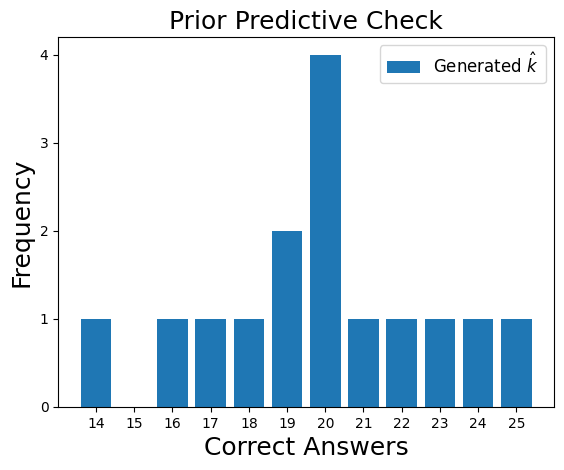

In [6]:
# The latent variables are: phi, p, z, 

# parameters
a = 3
b = 2
a_prime = 3
b_prime = 2
number_students = 15
number_questions = 40

# random sampling
p = np.random.beta(a, b)
phi = np.random.beta(a_prime, b_prime)
z = np.random.binomial(1, p, number_students)

theta = np.where(z == 0, phi, 0.5)

# generate new k vector
k_new = np.random.binomial(number_questions, theta, number_students)
lowest_k = min(k_new)
highest_k = max(k_new)
k_counter = Counter(k_new)
k_elements = list(k_counter.keys())
k_frequencies = list(k_counter.values())

#print(k_new)
#print(k_elements, k_frequencies)
#print(highest_k, lowest_k)
#print(k_counter)

# plot new k vector
plt.bar(k_elements, k_frequencies, label='Generated $\hat{k}$')
x_ticks = [i for i in range(lowest_k, highest_k + 1, 1)]
y_ticks = [i for i in range(0, max(k_frequencies) + 1)]

plt.xlabel("Correct Answers")
plt.ylabel("Frequency")
plt.xticks(x_ticks)
plt.yticks(y_ticks)
plt.title("Prior Predictive Check")
plt.legend()
plt.show()


##### Answer: Question 5
The properties of the model change a lot depending on the current random run.
In general, the data does not really look as clean as the actual data. The groups are a lot harder to differentiate and it is possible to achieve a lot of low scores even though that is not that drastic in the actual data.

6. Implement the model in JAGS and train it on the available data.

In [9]:
%%time 
n = 40
k = [19, 20, 16, 23, 22, 30, 38, 29, 34, 35, 35, 32, 37, 36, 33]
m = len(k)
a = 3
b = 2
a_prime = 3
b_prime = 2


jags_model = '''
model {
  for (i in 1:m) {
    k[i] ~ dbin(theta[i], n)
    z[i] ~ dcat(prob[])
    theta[i] <- phi * z[i] + psi * (1 - z[i])
  }

  p ~ dbeta(a, b)
  prob[1] <- 1 - p
  prob[2] <- p

  phi ~ dbeta(a_prime, b_prime)
  psi <- 0.5
}
'''


data = dict(n=n, k=k, m=m, a=a, b=b, a_prime=a_prime, b_prime=b_prime)

# How long we sample (we chose the same number as in the previous assignment)
num_iter = 30_000
# How many distinct sampling runs
num_chains = 4

model = pj.Model(jags_model, data=data, chains=num_chains)
samples = model.sample(num_iter, vars=['theta', 'phi', 'p', 'z'])

adapting: iterations 4000 of 4000, elapsed 0:00:00, remaining 0:00:00
sampling: iterations 120000 of 120000, elapsed 0:00:02, remaining 0:00:00
CPU times: user 2.21 s, sys: 155 ms, total: 2.36 s
Wall time: 2.65 s


7. Use the code below to make a ridge plot of $\theta_i$. Adapt the code to also show the maximum likelihood estimates for $\theta_i$ as a red vertical line, for each student. Are the distributions for $\theta_i$ consistent with MLEs?

##### Answer: Question 7
While some distributions align very well with the Maximum Likelihood Estimate, other distributions deviate substantially from the MLE.
Some distributions also show two peaks and sometimes the MLE is in between the two.

[<AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: xlabel='$θ_i$'>]

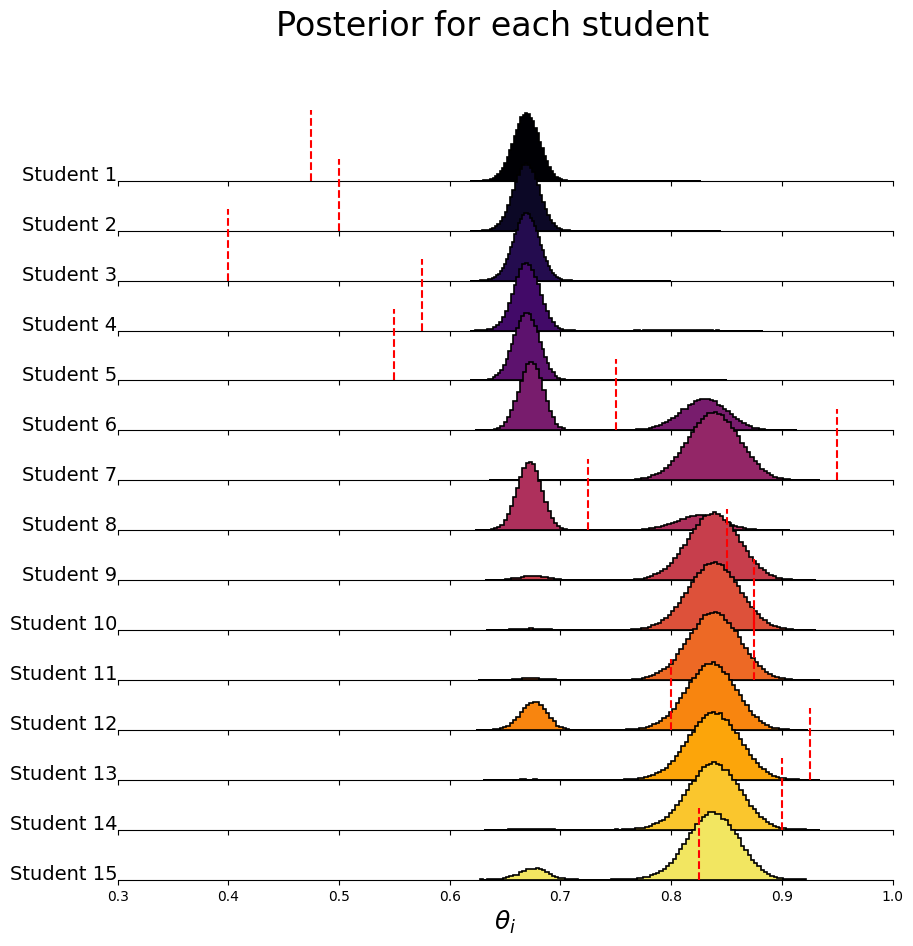

In [12]:
import matplotlib.gridspec as grid_spec
from scipy.stats import gaussian_kde

def ridge_plot(samples, xlimits, suptitle, xlabel, ylabel, theta_mle):
    """Make a ridge-plot figure.

    This function makes a ridge plot. It consists of a number of visually 
    overlapped smoothed histograms. 
    
    The dashed lines indicate the observed treatment effects, while the 
    histograms show what our model estimates.

    Args:
        samples: A numpy array of size m x num_samples x num_chains
        xlimits: the horizontal limits of the figures
        suptitle: the title to put above the figure
        xlabel: the name of the x-label
        ylabel: the name of each row
    """
    colors = plt.cm.get_cmap('inferno')
    J = samples.shape[0]
    gs = grid_spec.GridSpec(J, 1)
    fig = plt.figure(figsize=(10, 10))

    i = 0
    xmin, xmax = xlimits
    theta = np.linspace(xmin, xmax, num=200)    

    ax_objs = []
    for i in range(J):
        # creating new axes object
        ax_objs.append(fig.add_subplot(gs[i:i+1, 0:]))

        # plotting the distribution
        ax_objs[-1].hist(samples[i, :, :].flatten(), density=True, bins=100,
                         histtype='stepfilled', edgecolor='k', linewidth=1.2, color=colors(i/J))
        ax_objs[-1].axvline(theta_mle[i], color='red', linestyle='--', linewidth=1.5)

        # setting uniform x and y lims
        ax_objs[-1].set_xlim(xmin, xmax)
        ax_objs[-1].set_ylim(bottom=0)

        # make background transparent
        rect = ax_objs[-1].patch
        rect.set_alpha(0)

        # remove borders, axis ticks, and labels
        ax_objs[-1].set_yticklabels([])
        
        if i != J-1:
            ax_objs[-1].set_xticklabels([])            
        ax_objs[-1].text(xmin, 0.001, f'{ylabel} {i+1}',fontsize=14, ha="right")

        spines = ["top", "right", "left"]
        for s in spines:
            ax_objs[-1].spines[s].set_visible(False)
        ax_objs[-1].set_yticks([])
        i += 1

    ax_objs[-1].set_xlabel(xlabel)
    gs.update(hspace=-0.3)
    plt.suptitle(suptitle, fontsize=24)    
    return ax_objs

#
theta_samples = samples['theta']
theta_mle = np.array(k) / n

ridge_plot(
    samples=theta_samples,
    xlimits=(0.3, 1.0),
    suptitle="Posterior for each student",
    xlabel="$θ_i$",
    ylabel="Student",
    theta_mle=theta_mle
)

8. What are the posterior probabilities that a student has studied, for each of the $m$ students?

##### Answer: Question 8
To answer this question we assume that $z_i=1$ and we compute $p(z_i = 1 | data)$
In general the model seems very confident with the categories (which is slightly unsettling) so maybe the choice of the priors was not ideal.

In [15]:
z_samples = samples['z']
#print(z_samples.shape) # resulting shape is (15, 30000, 4) so (students, iterations, chains)

z_samples_per_student = z_samples.reshape(z_samples.shape[0], -1)
#print(z_samples_per_student.shape) # results in shape (15, 12000)

prob = np.mean(z_samples_per_student==1, axis=1) # should work because z values are either 0 or 1 and we add all 1s 
                                                # and divide by the total which gives the probability per row (axis=1)

#print(prob)
for i in range(z_samples.shape[0]):
    print(f"Student {i+1}: {prob[i]:.3f}")

Student 1: 1.000
Student 2: 1.000
Student 3: 1.000
Student 4: 0.996
Student 5: 0.998
Student 6: 0.538
Student 7: 0.001
Student 8: 0.711
Student 9: 0.034
Student 10: 0.012
Student 11: 0.013
Student 12: 0.183
Student 13: 0.002
Student 14: 0.004
Student 15: 0.082


## 1.2. Individual variability

The previous model makes a strong assumption: students that did study, all have the _same_ probability of answering a question correctly. That does not seem very realistic. 

1. Alter your generative model and your JAGS implementation to capture differences in performance among students that _did_ study. Make explicit what you changed compared to the previous model! In addition, make another ridge plot to show your updated results.

##### Answer: Question 1
The changes are marked in the code.
The updated results are shown below and this time the MLE aligns far better with the distributions but the distributions are also wider and not as narrow.

In [18]:
%%time 
n = 40
k = [19, 20, 16, 23, 22, 30, 38, 29, 34, 35, 35, 32, 37, 36, 33]
m = len(k)
a = 3
b = 2
alpha = 3
beta = 2


jags_model2 = '''
model {
  for (i in 1:m) {
    k[i] ~ dbin(theta[i], n)
    z[i] ~ dcat(prob[])

    # Adding the individual performance distribution 
    theta_distribution[i] ~ dbeta(alpha, beta) 

    # We do no longer use phi but the beta distribution from the line above
    theta[i] <- theta_distribution[i] * z[i] + psi * (1 - z[i])  

  }

  p ~ dbeta(a, b)
  prob[1] <- 1 - p
  prob[2] <- p

  psi <- 0.5
}
'''


data = dict(n=n, k=k, m=m, a=a, b=b, alpha=alpha, beta=beta)

# How long we sample (we chose the same number as in the previous assignment)
num_iter = 30_000
# How many distinct sampling runs
num_chains = 4

model2 = pj.Model(jags_model2, data=data, chains=num_chains)
samples2 = model2.sample(num_iter, vars=['theta', 'p', 'z'])

adapting: iterations 4000 of 4000, elapsed 0:00:00, remaining 0:00:00
sampling: iterations 120000 of 120000, elapsed 0:00:03, remaining 0:00:00
CPU times: user 3.2 s, sys: 72.7 ms, total: 3.28 s
Wall time: 3.53 s


[<AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: >,
 <AxesSubplot: xlabel='$θ_i$'>]

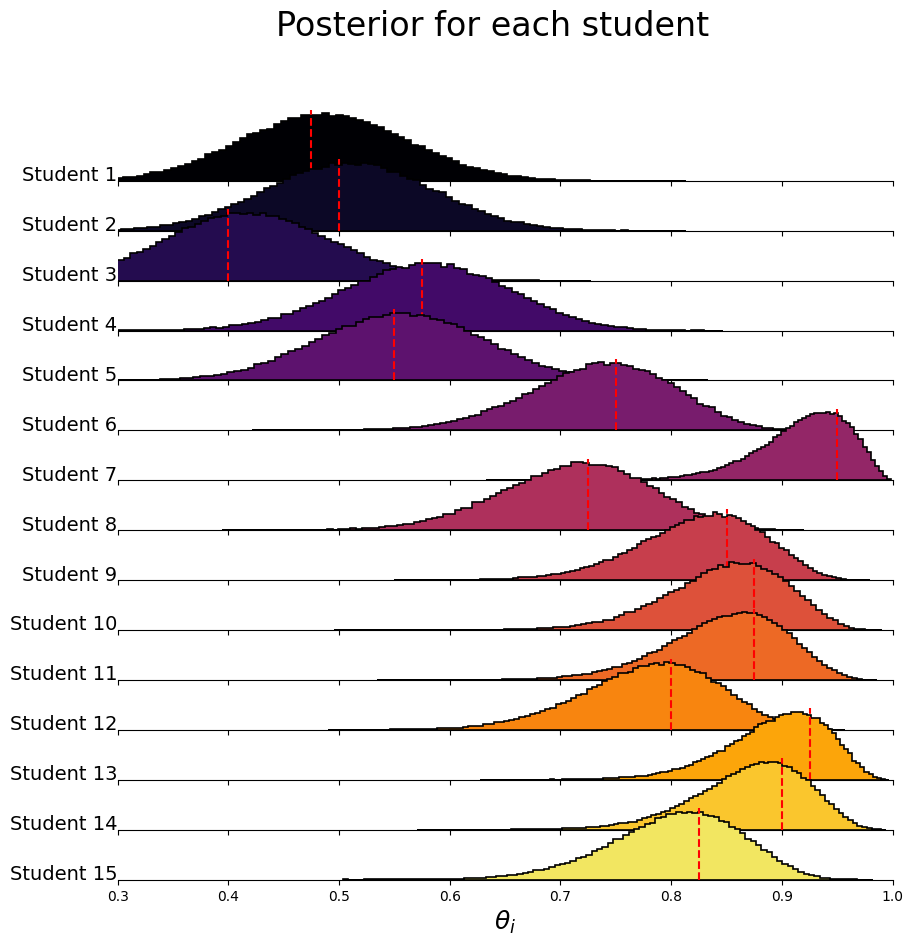

In [21]:
theta_samples_2 = samples2['theta']
theta_mle_2 = np.array(k) / n

ridge_plot(
    samples=theta_samples_2,
    xlimits=(0.3, 1.0),
    suptitle="Posterior for each student",
    xlabel="$θ_i$",
    ylabel="Student",
    theta_mle=theta_mle_2
)

2. Now print again the probabilities that each individual student has studied; print both the probability according to your first model and according to your second model. 



In [15]:
# Old model
z_samples = samples['z']
z_samples_per_student = z_samples.reshape(z_samples.shape[0], -1)
prob = np.mean(z_samples_per_student==1, axis=1) 

# New model
z_samples_2 = samples2['z']
z_samples_per_student_2 = z_samples_2.reshape(z_samples_2.shape[0], -1)
prob_2 = np.mean(z_samples_per_student_2==1, axis=1) 

print(f"{' ' * 12} Model 1 (Old) {' ' * 5} Model 2 (New)")
for i in range(z_samples_2.shape[0]):
    print(f"Student {i+1}: {' ' * 7}{prob[i]:.3f}{' ' * 12}{prob_2[i]:.3f}")



             Model 1 (Old)       Model 2 (New)
Student 1:        1.000            0.754
Student 2:        1.000            0.756
Student 3:        1.000            0.730
Student 4:        0.996            0.762
Student 5:        0.998            0.764
Student 6:        0.539            0.751
Student 7:        0.001            0.532
Student 8:        0.715            0.757
Student 9:        0.033            0.706
Student 10:        0.012            0.678
Student 11:        0.012            0.682
Student 12:        0.184            0.736
Student 13:        0.002            0.633
Student 14:        0.004            0.671
Student 15:        0.083            0.723


You should see that some probabilities have changed.

3. Why did adding the individual variability to the probability of a correct answer after studying, change the probability for students who performed poorly?

The new model does not consider it a strict fact that students that study necessarily perform better.
It accounts for the possibility that even when a student studies, they can still perform poorly.
Due to this, the probabilities for poor performance students also change.

## 1.3. Easy and tough exam questions

The previous model assumed that all questions were equal in difficulty. Of course, this is rarely the case in practice. Here, we construct a new model in which we represent both _student ability_ and _question difficulty_. 

To be able to model the difficulty of questions, we will not work with the aggregate results of the test (that is, the number of questions correct, previously $k_i$), but with the results for the individual questions. Now, $k_{ij}=1$ indicates that student $i$ answered question $j$ correctly. We will assume the probability of a question being answered correctly can be written as

$$
    \theta_{ij} = p_i q_j \enspace,
$$ 

in which $p_i$ is the probability student $i$ answers a question correctly, and $q_j$ is the probability question $j$ gets answered correctly. As you can see, even a student who is very smart ($p_i\approx 1$) might not answer correctly if a question is very difficult ($q_j\approx 0$).

Below are the results (observations) for $m=10$ students making $n=20$ questions.

In [24]:
k = np.array([[1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0 ],
              [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
              [0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],              
              [1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
              [0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
              [1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0],              
              [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
              [0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1],
              [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
              [1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]])

m, n = k.shape

1. Construct a generative model by which we can learn the individual student performances $p_i$ as well as the question difficulties $q_j$.

$k_{ij} \sim Bernoulli(\theta_{ij})$
$\theta_{ij} = p_i q_j$
$p_i \sim Beta(a, b)$
$q_j \sim Beta(a', b')$
a = 2
b = 2
alpha = 2
beta = 2

$k_{ij}$ indicates that student i answered question j correctly (copied from text)
$p_i$ is the probability student i answers a question correctly
$q_j$ is the probability question j gets answered correctly
a = b = alpha = beta = 2 are the hyperparameters for the beta distributions. Choosing 2 as a value does not introduce a very heavy bias but it is centered in the middle between 0 and 1.

2. Implement your model in JAGS. Visualize the posterior estimates of each $p_i$ and $q_j$ in a way you think is appropriate.

We decided to visualize the posterior with a kde plot because it shows every student in the same diagram and it is easy to see the overlaps between the students.

In [27]:
%%time 

jags_model3 = '''
model {
   for (i in 1:m) {
       for (j in 1:n) {
           k[i, j] ~ dbern(p[i] * q[j])
           
       }
   }
   for (i in 1:m) {
       p[i] ~ dbeta(a, b)
   }
   for (j in 1:n) {
       q[j] ~ dbeta(alpha, beta)
   }
}
'''
# The two following code lines were taken from ChatGPT because we encountered an error and did not know what the problem was.
# Pad matrix with extra row/column at index 0
k_jags = np.pad(k, ((1, 0), (1, 0)), mode='constant')

# Update shape for padded matrix
m, n = k_jags.shape


data = dict(n=n, k=k_jags, m=m, a=a, b=b, alpha=alpha, beta=beta)

# How long we sample
num_iter = 30000
# How many distinct sampling runs
num_chains = 4

model3 = pj.Model(jags_model3, data=data, chains=num_chains)
samples3 = model3.sample(num_iter, vars=['p', 'q'])

adapting: iterations 4000 of 4000, elapsed 0:00:00, remaining 0:00:00
sampling: iterations 61932 of 120000, elapsed 0:00:07, remaining 0:00:06
sampling: iterations 106948 of 120000, elapsed 0:00:12, remaining 0:00:01
sampling: iterations 120000 of 120000, elapsed 0:00:14, remaining 0:00:00
CPU times: user 12.9 s, sys: 276 ms, total: 13.2 s
Wall time: 14.1 s


3. According to your model, which students performed best, and which questions where the most difficult?

Tip: for this 'sorting', it might be easiest to compute for each $p_i$ or $q_j$ the _mode_ of the distribution and sort according to this.

---
# 2. Let's milk this further with Bayesian regression

In an attempt to produce productivity, farmer Fred decides to start cuddling his cows for a testing period of one month. For each cow, Fred writes down the number of cuddles she received ($x_i$) as well as the total amount of milk they produced that month ($y_i$; in liters).

The following code snippet loads and visualizes Fred's data set.

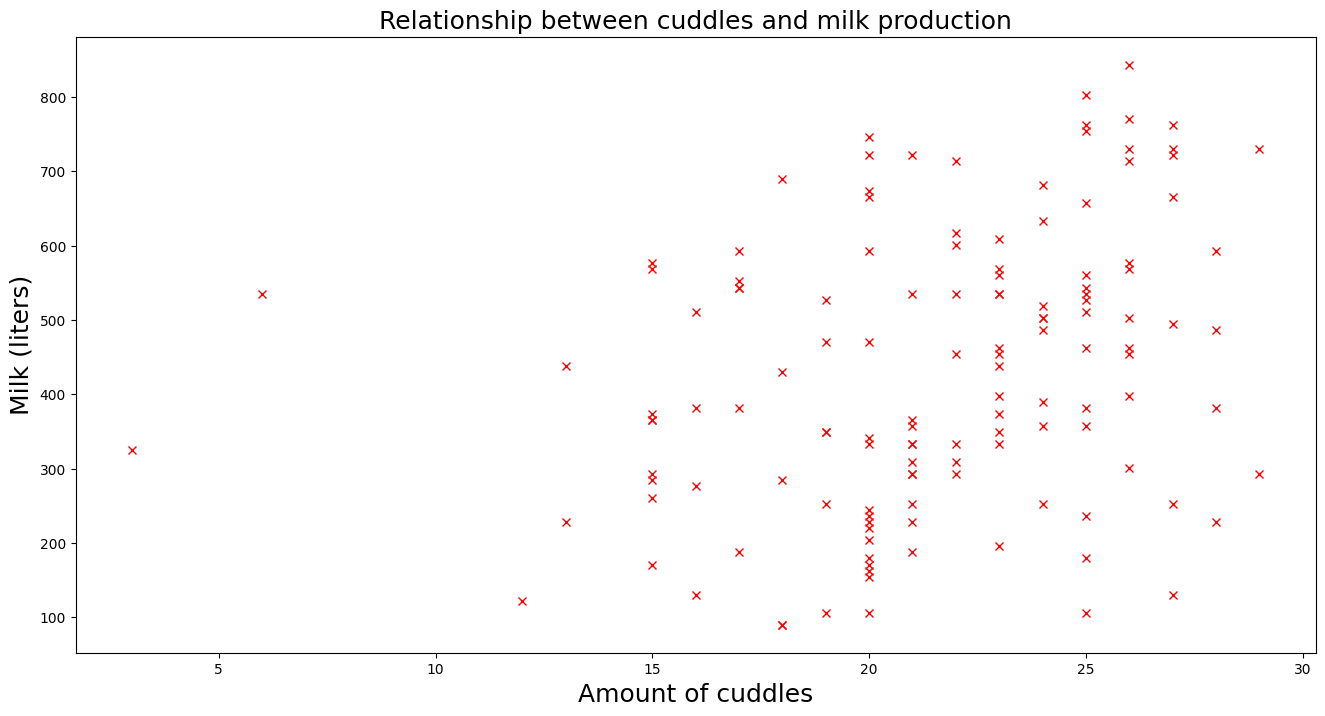

In [30]:
import pandas as pd

df = pd.read_csv('cow_cuddles_fred.csv', delimiter=';', decimal=',', header=None)
x = df[0].to_numpy()
y = df[1].to_numpy()
n = len(y)


plt.figure(figsize=(16, 8))
plt.plot(x, y, 'rx')
plt.xlabel('Amount of cuddles')
plt.ylabel('Milk (liters)')
plt.title('Relationship between cuddles and milk production');

1. Implement a Bayesian linear regression model in JAGS.

In [33]:
%%time

code = '''
model{
    # Priors
    alpha ~ dnorm(0, 1.0/10000)      # Intercept prior (wide normal)
    beta ~ dnorm(0, 1.0/10000)        # Slope prior (wide normal)
    sigma ~ dunif(0, 100)             # Standard deviation prior (uniform)
    tau <- 1/(sigma*sigma)            # Precision
    
    # Likelihood
    for(i in 1:n){
        y[i] ~ dnorm(mu[i], tau)
        mu[i] <- alpha + beta*x[i]
    }
}
'''

data = dict(x=x, y=y, n=len(y))

num_samples = 30000
num_chains = 4

m = pj.Model(code=code, data=data, chains=num_chains)
samples = m.sample(num_samples, vars=['alpha', 'beta', 'sigma'])

adapting: iterations 4000 of 4000, elapsed 0:00:00, remaining 0:00:00
sampling: iterations 120000 of 120000, elapsed 0:00:05, remaining 0:00:00
CPU times: user 4.65 s, sys: 29.4 ms, total: 4.68 s
Wall time: 4.92 s


2. Use your MCMC samples to visualize the posterior distribution of $\mu=w_0+w_1 x$ for a range of $x$, e.g., `x_plot = np.linspace(0, 30, num=100)`, by showing the posterior expectation and the 95% HDI (see Lecture 6). 

Tip: To construct the posterior of $\mu$, you will need the samples of the regression weights ($w_0$ and $w_1$). You could, for every MCMC sample $s$, take $w_0^{(s)}$ and $w_1^{(s)}$ and construct the vector $\mathbf{\mu}^{(s)}$ for each (this vector is of length 100, as `x` was constructed to have that length). However, doing this in a `for` loop can be very slow! It is much faster (i.e., more than 100 times) to add/multiply entire `numpy` matrices/arrays at once.

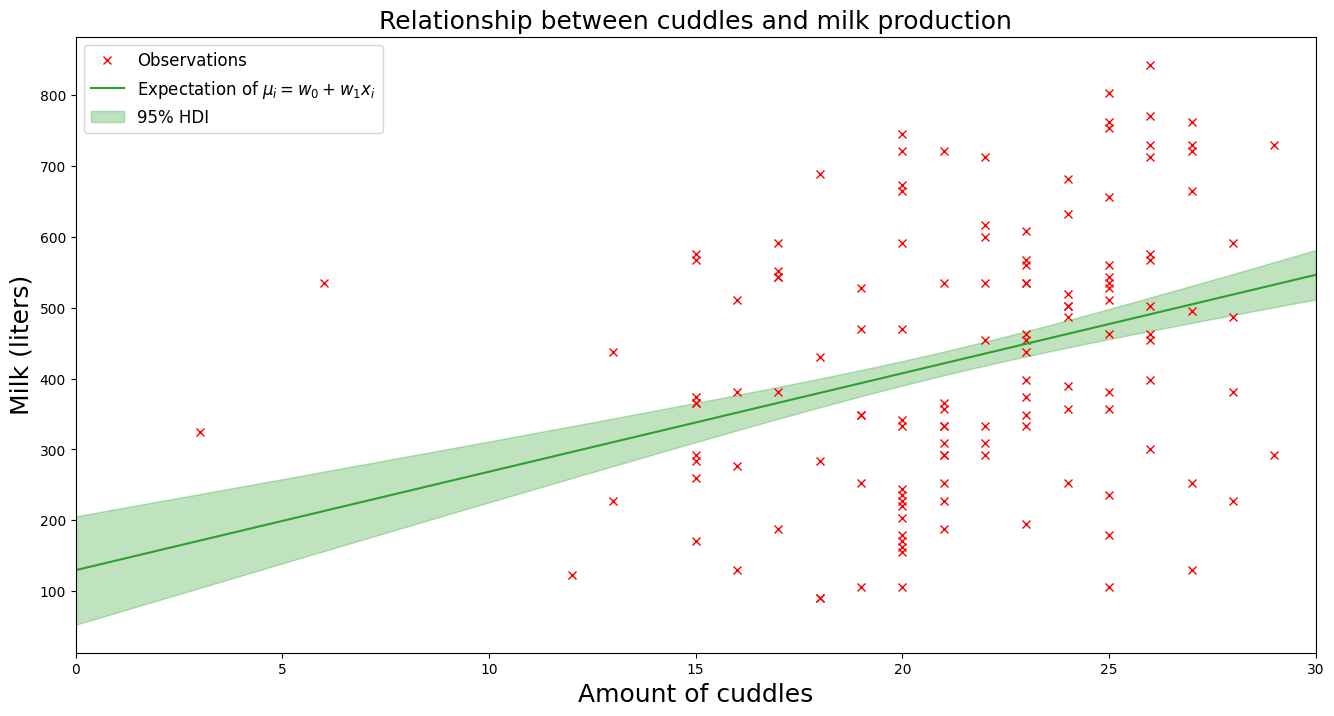

In [36]:
plt.figure(figsize=(16, 8))
ax = plt.gca()
ax.plot(x, y, 'rx', label='Observations')

m = 100
x_plot = np.linspace(0, 30, num=m)
w0_samples = samples['alpha'].flatten() 
w1_samples = samples['beta'].flatten()   

x_repeat = np.repeat(x_plot[:, np.newaxis], num_samples*num_chains, axis=1).T
w0_repeat = np.repeat(w0_samples[:, np.newaxis], m, axis=1)  
w1_repeat = np.repeat(w1_samples[:, np.newaxis], m, axis=1) 

mu_samples = w0_repeat + w1_repeat * x_repeat

mu_exp = np.mean(mu_samples, axis=0)     
mu_lower =np.percentile(mu_samples, 2.5, axis=0)  
mu_upper = np.percentile(mu_samples, 97.5, axis=0)  # get the upper limit of the 95% HDI # shape: (m,)

ax.plot(x_plot, mu_exp, color='tab:green', 
        label=r'Expectation of $\mu_i = w_0 + w_1x_i$')
ax.fill_between(x_plot, 
                mu_lower,
                mu_upper, color='tab:green', alpha=0.3, label='95% HDI')
ax.legend()
plt.xlabel('Amount of cuddles')
plt.ylabel('Milk (liters)')
plt.title('Relationship between cuddles and milk production')
ax.set_xlim([x_plot[0], x_plot[-1]]);

---
__IMPORTANT__

Something we have not discussed at length is the relationship between our priors and the _scale_ of the data. If you have used a fairly standard prior for your regression weights, such as $w_1 \sim \text{Gaussian}(0, 1)$, you are saying in your prior that you expect only _small_ changes to the amount of milk as a function of an increase in number of cuddles. However, the amount of milk is measured in _hundreds_ of liters. If there indeed is an effect, that means that $w_1$ could have a true value such as 20 (for every additional cuddle, 20 more liters produced) -- which is extremely unlikely under the $\text{Gaussian}(0, 1)$ prior. 

The result of such a 'wrong' prior specification can be that the model learns there is almost no effect, and that all observations are just explained by a (nearly) horizontal regression line and a large measurement noise $\sigma$ (the standard deviation of the Gaussian likelihood).

If this happens in your analysis, you have used a prior that is too restrictive (or we simply don't have enough data). It is easily fixed; just make your priors _wider_. For example, use $\text{Gaussian}(0, \sigma=10)$ instead (remember that in JAGS that would be `dnorm(0, 1/pow(10,2))`.

Make sure your posterior expectation of the regression looks reasonable before proceeding!

---

3. Make a histogram of the posterior of the standard deviation $\sigma$. Does it show reasonable values compared to your previous figure (for example, at $x=20$, our observations range from roughly 80 to 750; our standard deviation therefore should not be 4, or 2000)?

In the histogram for the posterior of the standard deviation, the main part of the distribution is located at the far right and seems to be cut off.
The standard deviation is likely going to be above 100 because the observations range from about 80 to 750. It seems unlikely, given this information, that the standard deviation is cut off above 100.

Text(0, 0.5, 'Frequency')

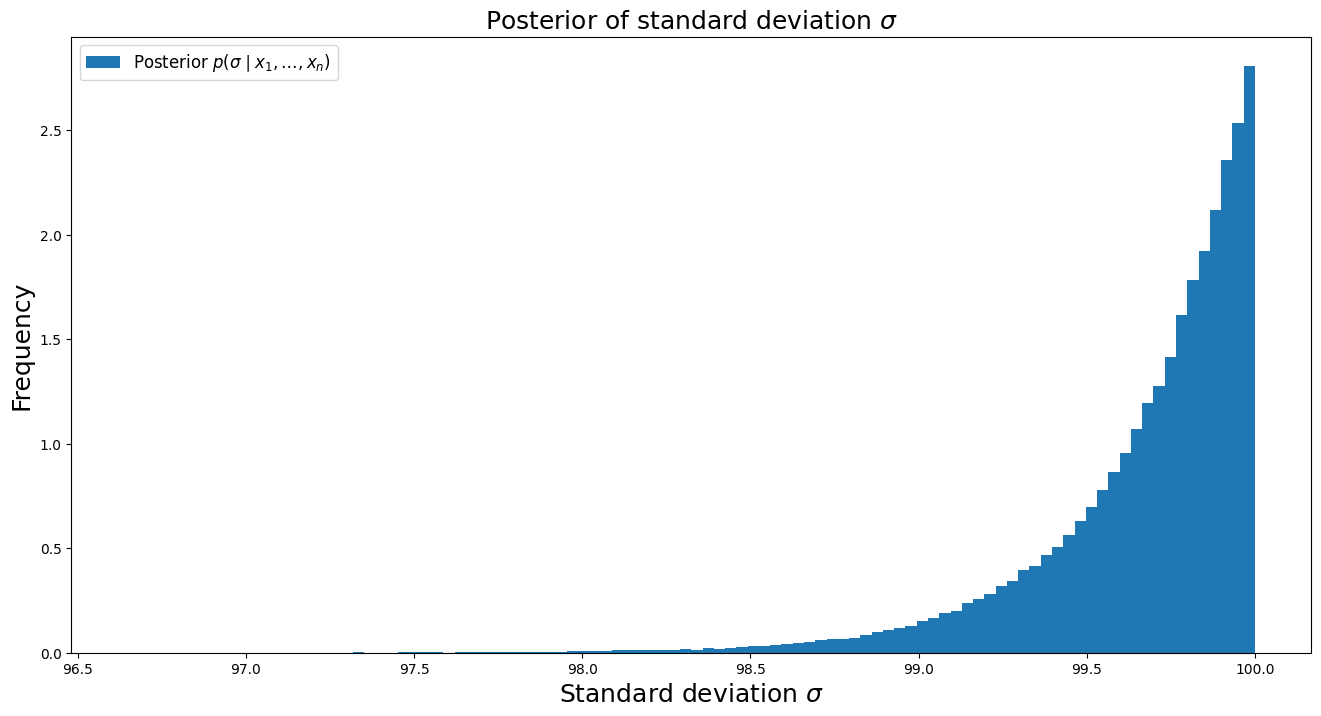

In [39]:
plt.figure(figsize=(16,8))
ax = plt.gca()
ax.hist(samples['sigma'].flatten(), density=True, bins=100, 
        label=r'Posterior $p(\sigma \mid x_1, \ldots, x_n)$')
ax.legend()
ax.set_title('Posterior of standard deviation $\sigma$');
ax.set_xlabel('Standard deviation $\sigma$')
ax.set_ylabel('Frequency')


The previous questions asked you to visualize the posterior distributions of the vector $\mu$ and the scalar $\sigma$. But to know what happens when Fred cuddles a new cow for 40 times ($x^*=40$), we need the _posterior predictive_ distribution instead.

4. Plot a histogram of the (approximated) posterior predictive distribution: $p(y^* \mid x^*, x_1, \ldots, x_n)=\int p(y^* \mid w_0, w_1, \sigma, x^*)p(w_0, w_1, \sigma \mid x_1, \ldots, x_n) \text{d}w_0 \text{d}w_1 \text{d}\sigma$. In the same figure, plot another histogram (with a different color) of $\mu^*$, and a vertical line (using `axvline`) with the posterior expectation of $\mu^*$.

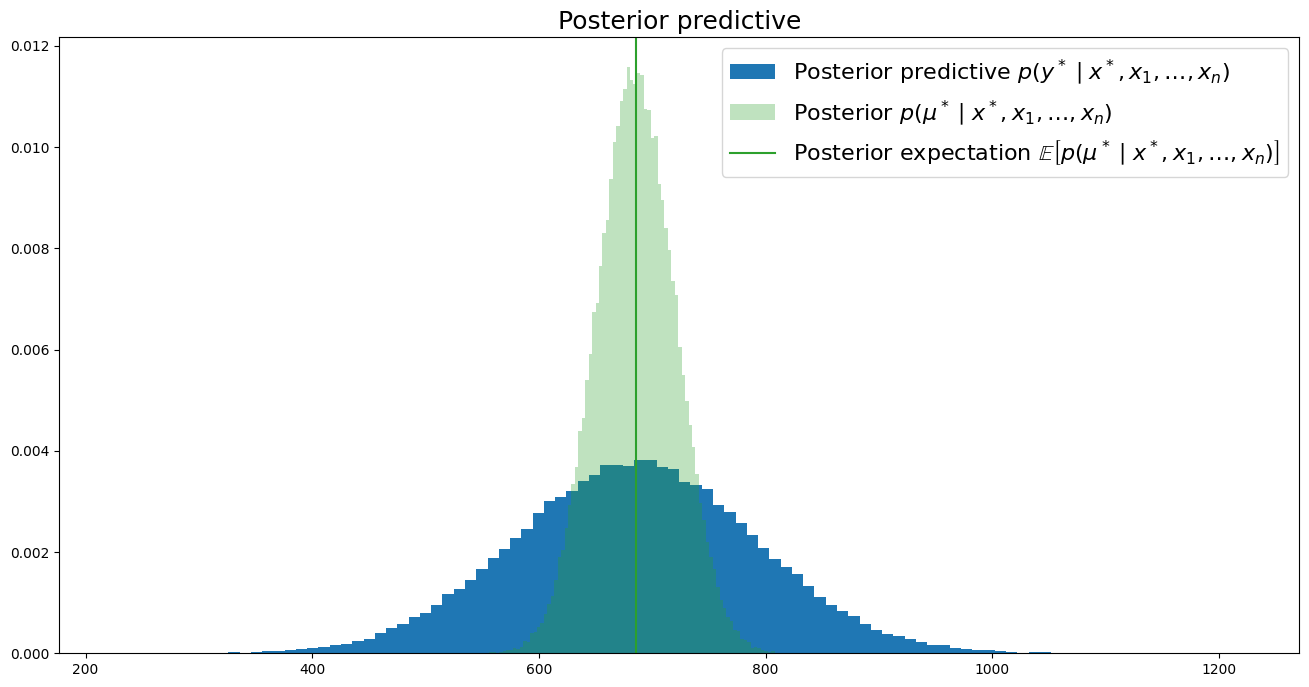

In [42]:
x_pred = 40


# Get posterior samples
w0_samples = samples['alpha'].flatten()
w1_samples = samples['beta'].flatten()
sigma_samples = samples['sigma'].flatten()

mu_pred = w0_samples + w1_samples * x_pred #μ* = w0 + w1*x_pred for all samples


y_pred = np.random.normal(loc=mu_pred, scale=sigma_samples) # Generate predictive samples y* ~ N(μ*, σ)

plt.figure(figsize=(16,8))
ax = plt.gca()
ax.hist(y_pred, density=True, bins=100, 
        label='Posterior predictive $p(y^* \mid x^*, x_1, \ldots, x_n)$')
ax.hist(mu_pred, density=True, bins=100, alpha=0.3, color='tab:green',
        label=r'Posterior $p(\mu^* \mid x^*, x_1, \ldots, x_n)$')
ax.axvline(x=np.mean(mu_pred), color='tab:green', 
           label=r'Posterior expectation $\mathbb{E}\left[p(\mu^* \mid x^*, x_1, \ldots, x_n)\right]$')
ax.legend(fontsize=16)
ax.set_title('Posterior predictive');

Neighbouring farmer Francesco learns of Fred's results and decides to start cuddling her cows as well. She follows a similar procedure, and below you can see her observations.

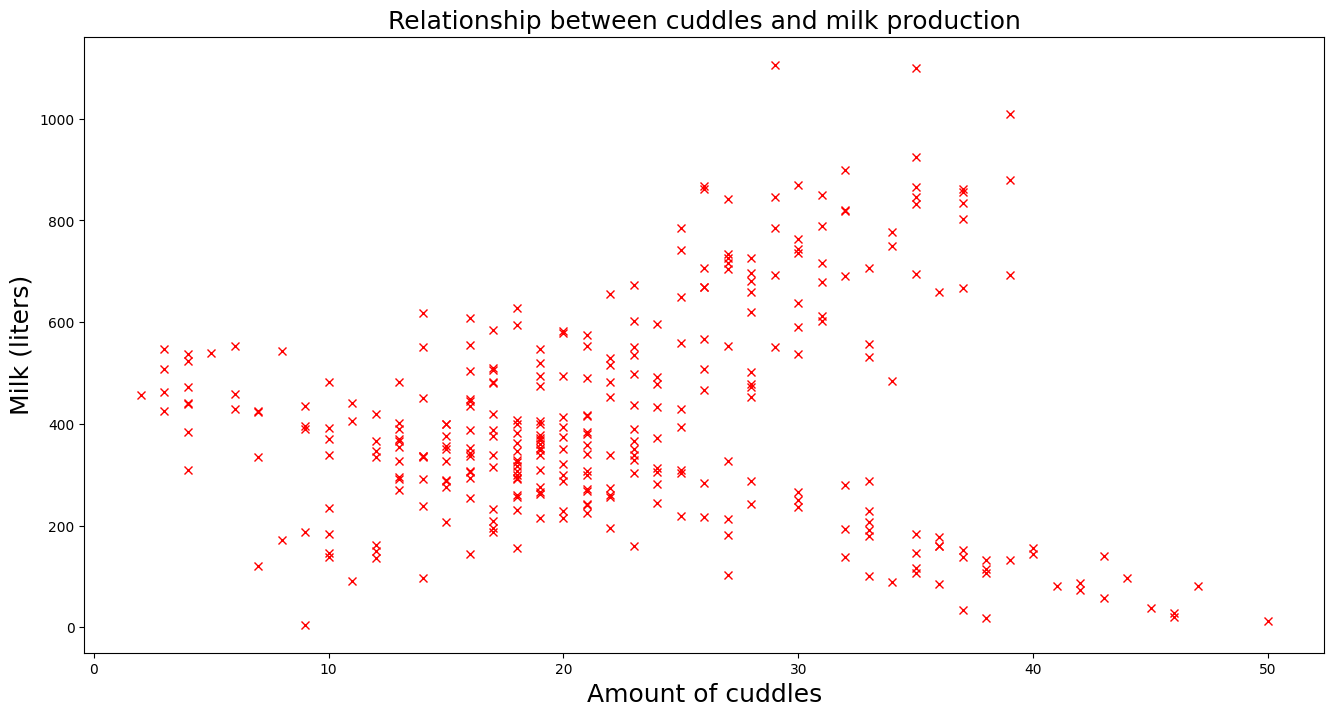

In [45]:
import pandas as pd

df = pd.read_csv('cow_cuddles_francesca.csv', delimiter=';', decimal='.', header=None)
x = df[0].to_numpy()
y = df[1].to_numpy()
n = len(y)

plt.figure(figsize=(16, 8))
plt.plot(x, y, 'rx')
plt.xlabel('Amount of cuddles')
plt.ylabel('Milk (liters)')
plt.title('Relationship between cuddles and milk production');

Remarkably, the effect is a lot less clear than it was for Fred. In fact, it seems like there are two trends occurring in parallel: one group of cows benefits from cuddles, just like with Fred, but another group of cows seems to produce _less_ milk after receiving cuddles. Perhaps these are a different breed that are not so appreciative of hugging people?

5. Anyway, demonstrate that modelling these data with your Bayesian linear regression model leads to poor predictions, by showing the actual observations at $x=35$ and the posterior predictive distribution.

In [91]:
%%time

code = '''
model{
    # Priors
    alpha ~ dnorm(0, 1.0/100)  # Intercept
    beta ~ dnorm(0, 1.0/100)    # Slope
    sigma ~ dunif(0, 100)       # Standard deviation
    
    # Likelihood
    for(i in 1:n){
        y[i] ~ dnorm(mu[i], 1/(sigma*sigma))
        mu[i] <- alpha + beta*x[i]
    }
}
'''

data = { 'x': x, 'y': y, 'n': len(y)}
num_samples = 30000
num_chains = 4

m = pj.Model(code=code, data=data, chains=num_chains)
samples = m.sample(num_samples, vars=['alpha', 'beta', 'sigma'])

adapting: iterations 4000 of 4000, elapsed 0:00:00, remaining 0:00:00
sampling: iterations 59772 of 120000, elapsed 0:00:05, remaining 0:00:05
sampling: iterations 120000 of 120000, elapsed 0:00:10, remaining 0:00:00
CPU times: user 9.8 s, sys: 54.6 ms, total: 9.85 s
Wall time: 10 s


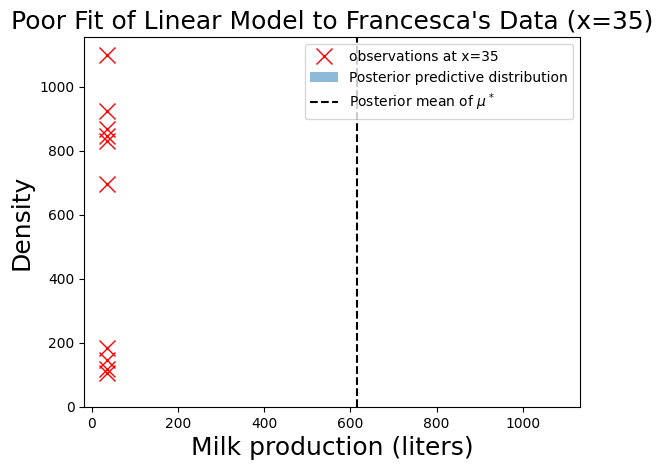

In [48]:
x_pred = 35

alpha = samples['alpha'] 
beta =  samples['beta']
sigma = samples['sigma']
mu_pred =alpha  + beta * x_pred
y_pred = np.random.normal(loc=mu_pred, scale=sigma)

ax = plt.gca()

obs_mask = (x > 34) & (x < 36)
ax.plot(x[obs_mask], y[obs_mask], 'rx', markersize=12, label='observations at x=35')

ax.hist(y_pred.flatten(), density=True, bins=100, alpha=0.5, label='Posterior predictive distribution')
ax.axvline(np.mean(mu_pred), color='black', linestyle='--', label='Posterior mean of $\mu^*$')

ax.legend(fontsize=10)
ax.set_title('Poor Fit of Linear Model to Francesca\'s Data (x=35)')
plt.xlabel('Milk production (liters)')
plt.ylabel('Density')
plt.show()

To better model these observations, we need a _mixture model_. However, instead of a Gaussian mixture model like in the lecture, we now need a Bayesian linear regression mixture model.

6. Write down the generative model for the Bayesian linear regression mixture model. You may assume there are $K=2$ components.

##### Generative Model:
$\pi \sim Dirichlet(1, 1)$

Components 1 and 2:
$\alpha_k \sim N(0, 100)$
$\beta_k \sim N(0, 100)$
$\sigma_k \sim Uniform(0, 100)$

Observations 1...n:
$z_i \sim Categorical(\pi)$
$\mu_i \sim \alpha_{z_i} + \beta_{z_i} \cdot x_i$
$y_i \sim N(\mu_i, \sigma_i^2)$

$\pi$ is a prior over two components. The parameters 1, 1 mean that it is a uniform prior.

7. Implement your model in JAGS. Make sure to consider the tips in Lecture 6 on keeping the components identifiable!

__Note__: As mentioned in the lecture, this model can take quite a bit longer to sample. My solution took about a minute on a Google colab environment.

In [115]:
%%time

code = '''
model {
  pi[1:2] ~ ddirch(c(1, 1))

  # Components
  for (k in 1:2) {
    alpha[k] ~ dnorm(0, 1.0/100)
    beta[k]  ~ dnorm(0, 1.0/100)
    sigma[k] ~ dunif(0, 100)
    tau[k] <- 1 / (sigma[k]^2)
  }

  # Likelihood
  for (i in 1:n) {
    z[i] ~ dcat(pi[])                      # Latent component assignment
    mu[i] <- alpha[z[i]] + beta[z[i]] * x[i]
    y[i] ~ dnorm(mu[i], tau[z[i]])
  }
}
'''

data = dict(x=x, y=y, n=len(y))
num_samples = 30000
num_chains = 4

m = pj.Model(code=code, data=data, chains=num_chains)
samples = m.sample(num_samples, vars=['alpha', 'beta', 'sigma', 'z', 'pi'])

adapting: iterations 4000 of 4000, elapsed 0:00:05, remaining 0:00:00
sampling: iterations 8428 of 120000, elapsed 0:00:10, remaining 0:02:07
sampling: iterations 17292 of 120000, elapsed 0:00:19, remaining 0:01:54
sampling: iterations 21784 of 120000, elapsed 0:00:25, remaining 0:01:54
sampling: iterations 26080 of 120000, elapsed 0:00:31, remaining 0:01:51
sampling: iterations 30324 of 120000, elapsed 0:00:36, remaining 0:01:46
sampling: iterations 38796 of 120000, elapsed 0:00:46, remaining 0:01:35
sampling: iterations 43052 of 120000, elapsed 0:00:51, remaining 0:01:31
sampling: iterations 51560 of 120000, elapsed 0:01:00, remaining 0:01:20
sampling: iterations 55840 of 120000, elapsed 0:01:05, remaining 0:01:15
sampling: iterations 60104 of 120000, elapsed 0:01:11, remaining 0:01:11
sampling: iterations 68596 of 120000, elapsed 0:01:20, remaining 0:01:00
sampling: iterations 72860 of 120000, elapsed 0:01:25, remaining 0:00:55
sampling: iterations 81380 of 120000, elapsed 0:01:36, 

8. Visualize once more the posterior distribution of $\mu$ (expectation + 95% HDI), for `x_plot = np.linspace(0, 50, num=100)`. This time however, the plot should show two distinct $\mu$'s (and their 95% HDI); one for each mixture component.

In [ ]:
plt.figure(figsize=(16, 8))
ax = plt.gca()
ax.plot(x, y, 'rx', label='Observations')

m = 100
x_range = np.linspace(0, 50, num=m)

...

colors = ['tab:green', 'tab:orange']

for k in range(2):
    ...
    ax.plot(x_range, ..., color=colors[k], 
            label=f'Expectation of component {k+1}')
    ax.fill_between(x_range, 
                    mu_lower,
                    mu_upper, color=colors[k], alpha=0.3, 
                    label=f'95% HDI of component {k+1}')

ax.legend()
ax.set_xlabel('Amount of cuddles')
ax.set_ylabel('Milk (liters)')
ax.set_title('Relationship between cuddles and milk production')
ax.set_xlim([x_range[0], x_range[-1]]);

9. Show the posterior predictive distribution for $x^*=35$. Explain the differences in this figure compared to your result for subquestion 4.

Tip: Simply showing the two posterior predictives for the two regressions is not sufficient. That would show two separate posterior predictive distributions, instead of one single distribution (i.e., it would integrate to 2 instead of 1 -- see the lecture slides). Instead, for each predictive sample $y^{(s)}$ you first need to sample $z^{(s)} \sim \text{Categorical}({\pi})$, where $\pi$ is the posterior probability that a point belongs to either component 1 or component 2. Then, once you know the label of the sampled point, you can take the appropriate $w_0$, $w_1$ and $\sigma$ to predict. Repeat this for all samples, and you collect the histogram of $p(y^* \mid x^*, x_1, \ldots, x_n)$.

In [ ]:
%%time 
x_pred = 35

mu_samples = ...
sigma_samples = ...
pi_samples = ...


y_pred = np.empty((num_chains*num_samples, ))

for j in range(num_samples*num_chains):    
    z_j = np.random.binomial(n=1, p=pi_samples[1, j], size=1)
    
    y_pred[j] = np.random.normal(loc=..., scale=...)


plt.figure(figsize=(16,8))
ax = plt.gca()
ax.hist(y_pred, density=True, bins=100, 
        label='Posterior predictive $p(y^* \mid x^*=35, x_1, \ldots, x_n)$')
ax.hist(y[x==x_pred], density=True, bins=100, alpha=0.3, color='tab:green',
        label=r'Observations at $x={:d}$'.format(x_pred))
ax.legend(fontsize=16)
ax.set_title('Posterior predictive');

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b076f4e6-863b-45d6-a4d3-a3de5d93b110' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>